In [61]:
# === Backtesting Engine: 2021 - 2023 (Monthly Rebalance, 3-Month Rolling Window) ===
# Metodologi berdasarkan Kombinasi_GT_Ising.pdf: Discrete Markowitz as Exact Potential Game
# dengan Normalized Mutual Information (NMI) dan Nash Equilibrium (SBR).

import yfinance as yf
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt
from itertools import combinations
import warnings

warnings.filterwarnings('ignore')

print("Starting Setup for Backtesting (2021-2023)...")


Starting Setup for Backtesting (2021-2023)...


In [62]:
# =============================================================================
# 1. Konfigurasi
# =============================================================================
tickers = ['BBCA.JK', 'TLKM.JK', 'SMGR.JK',
           'KLBF.JK', 'ASII.JK', 'UNTR.JK'
           ]
N       = len(tickers)       # Jumlah aset kandidat
K       = 2                  # Jumlah aset target portofolio
penalty_A = 5.0              # Pengali Lagrange (A) untuk H_penalty (lambda)

# Parameter Kalender
initial_capital = 100_000_000.0
lookback_days  = 126   # ~6 bulan perdagangan
rebalance_days = 21   # ~1 bulan perdagangan

# =============================================================================
# 2. Download Data
# =============================================================================
data = yf.download(tickers, start="2020-09-01", end="2024-01-01", progress=False)['Close']
data = data.dropna()
data_clean = data.sort_index()

# Mengunduh data indeks pembanding: ^ihsg
idx_data = yf.download('^GSPC', start='2021-01-04', end='2024-01-01', progress=False)['Close']
idx_data = idx_data.dropna()
idx_rets = idx_data.pct_change().dropna()

print(f"Data Berhasil Diunduh. Total hari observasi: {len(data_clean)}")


Data Berhasil Diunduh. Total hari observasi: 813


In [63]:
# =============================================================================
# 3. Helper: Endogenous Lambda (Risk-Aversion Parameter)
# =============================================================================
def compute_endogenous_lambda(log_returns, tickers):
    """
    Menghitung parameter risk-aversion (gamma) secara endogen berdasarkan
    Sharpe Ratio rata-rata lintas aset, menggunakan fungsi sigmoid/logistik.
    """
    mu_annual    = log_returns[tickers].mean() * 252
    sigma_annual = log_returns[tickers].std()  * np.sqrt(252)
    mu_avg    = abs(mu_annual).mean()
    sigma_avg = sigma_annual.mean()
    if np.isnan(mu_avg) or np.isnan(sigma_avg) or (mu_avg + sigma_avg) == 0:
        return 0.5
    Z = mu_avg / sigma_avg   # Sharpe Ratio agregat
    return 1.0 / (1.0 + np.exp(Z))

# =============================================================================
# 4. Helper: Strategic Returns & Information Matrix (NMI)
# =============================================================================
def compute_strategic_returns(log_rets, binary_st, tickers):
    """
    [Tugas 2: Perhitungan Imbal Hasil Strategis]
    Menghitung imbal hasil strategis (mu_tilde_i) sebagai jumlahan terbobot
    dari ekspektasi bersyarat pada 16 microstates sistem 4 aset.
    """
    n_assets = len(tickers)
    total_days = len(log_rets)
    mu_tilde = np.zeros(n_assets)

    # Kelompokkan return berdasarkan binary states (microstates) dari semua aset
    grouped = log_rets.groupby([binary_st[t] for t in tickers])

    for state, group in grouped:
        P_s = len(group) / total_days           # Probabilitas microstate P(s)
        R_bar_s = group[tickers].mean().values  # Ekspektasi return bersyarat R_bar_i(s)
        mu_tilde += P_s * R_bar_s               # Jumlahan terbobot

    return mu_tilde

def calc_shannon_entropy(st_A):
    """[Tugas 1] Menghitung entropi Shannon H(X) dari distribusi probabilitas biner."""
    p1 = np.mean(st_A)
    p0 = 1.0 - p1
    H = 0.0
    if p0 > 0: H -= p0 * np.log2(p0)
    if p1 > 0: H -= p1 * np.log2(p1)
    return H

def calc_classical_mutual_information(st_A, st_B):
    """[Tugas 1] Menghitung Classical Mutual Information I(X_i; X_j)."""
    n_ij = np.zeros((2, 2))
    for t in range(len(st_A)):
        n_ij[int(st_A[t]), int(st_B[t])] += 1

    prob_joint = n_ij / len(st_A)
    prob_A = prob_joint.sum(axis=1)
    prob_B = prob_joint.sum(axis=0)

    I_MI = 0.0
    for i in range(2):
        for j in range(2):
            if prob_joint[i, j] > 0:
                I_MI += prob_joint[i, j] * np.log2(prob_joint[i, j] / (prob_A[i] * prob_B[j]))
    return max(I_MI, 0.0)

def calc_NMI(st_A, st_B):
    """
    [Tugas 1] Menghitung Normalized Mutual Information (NMI)
    menggunakan Upper Bound Theorem: NMI(i,j) = I(X_i:X_j) / sqrt(H(X_i)*H(X_j)).
    """
    I_AB = calc_classical_mutual_information(st_A, st_B)
    H_A = calc_shannon_entropy(st_A)
    H_B = calc_shannon_entropy(st_B)

    if H_A == 0 or H_B == 0:
        return 0.0

    return I_AB / np.sqrt(H_A * H_B)

# =============================================================================
# 5. Helper: Nash Equilibrium Search
# =============================================================================
def calculate_energy(x, h, J, N):
    Z = 1 - 2 * x
    E = 0.0
    for i in range(N):
        E += h[i] * Z[i]
        for j in range(i + 1, N):
            E += J[i, j] * Z[i] * Z[j]
    return E

def find_nash_sbr(h, J, N=4, K=2, max_iters=100):
    """
    Pencarian Nash Equilibrium menggunakan Sequential Best Response (SBR).
    Sangat efisien untuk jumlah aset (N) yang besar di mana brute force tidak mungkin.
    """
    current_selection = set(range(K))

    def get_energy(selection):
        x = np.zeros(N)
        for idx in selection: x[idx] = 1
        Z = 1 - 2 * x
        E = np.dot(h, Z)
        for i in range(N):
            for j in range(i + 1, N):
                E += J[i, j] * Z[i] * Z[j]
        return E

    current_energy = get_energy(current_selection)

    for _ in range(max_iters):
        improved = False
        out_portfolio = set(range(N)) - current_selection

        best_swap = None
        min_energy = current_energy

        for i in current_selection:
            for j in out_portfolio:
                new_selection = (current_selection - {i}) | {j}
                new_energy = get_energy(new_selection)

                if new_energy < min_energy:
                    min_energy = new_energy
                    best_swap = (i, j)

        if best_swap:
            i, j = best_swap
            current_selection = (current_selection - {i}) | {j}
            current_energy = min_energy
            improved = True

        if not improved:
            break

    final_x = np.zeros(N, dtype=int)
    for idx in current_selection: final_x[idx] = 1
    return "".join(str(bit) for bit in final_x), current_energy



In [64]:
# =============================================================================
# 6. Pipeline Strategi Per Rebalancing Step
# =============================================================================
def run_strategy_step(lookback_data, tickers, K=2, penalty_A=5.0, lambda_nmi=0.0):
    """
    Eksekusi satu periode pembelajaran.
    Mengimplementasikan formulasi objektif PDF dengan Nash Equilibrium.
    """
    n_assets = len(tickers)
    log_rets  = np.log(lookback_data / lookback_data.shift(1)).dropna()
    binary_st = (log_rets <= 0).astype(int)   # 1 = turun, 0 = naik

    # gamma disini mewakili degree of risk-aversion, yang diestimasi serupa endogenous lambda
    gamma = compute_endogenous_lambda(log_rets, tickers)
    lam = penalty_A # penalty lambda untuk pembatas kardinalitas

    # [Tugas 2] Perhitungan Imbal Hasil Strategis
    mu_tilde = compute_strategic_returns(log_rets, binary_st, tickers)

    # [Tugas 1] Modifikasi Matriks Kovariansi dengan NMI
    cov_emp = log_rets.cov().values
    sigma_tilde = np.zeros((n_assets, n_assets))

    for i in range(n_assets):
        for j in range(n_assets):
            if i == j:
                sigma_tilde[i, i] = cov_emp[i, i]
            else:
                nmi_val = calc_NMI(binary_st[tickers[i]].values, binary_st[tickers[j]].values)
                # Formula penyusuaian kovariansi
                sigma_tilde[i, j] = cov_emp[i, j] + lambda_nmi * nmi_val

    # [Tugas 3] Konstruksi Model Ising Sesuai PDF
    h_total = np.zeros(n_assets)
    J_total = np.zeros((n_assets, n_assets))

    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            # Formula kopling J_ij
            J_val = (gamma * sigma_tilde[i, j] + 2 * lam) / 4.0
            J_total[i, j] = J_val
            J_total[j, i] = J_val

    for i in range(n_assets):
        sum_J_ij = 0.0
        for j in range(n_assets):
            if i != j:
                sum_J_ij += (gamma * sigma_tilde[i, j] + 2 * lam) / 4.0

        # Formula bias lokal h_i
        h_total[i] = -0.5 * ((gamma / 2.0) * sigma_tilde[i, i] - mu_tilde[i] + lam * (1.0 - 2.0 * K)) - sum_J_ij

    # [Tugas 4] Pencarian Nash Equilibrium
    ne_bitstring, ne_energy = find_nash_sbr(h_total, J_total, N=n_assets, K=K)

    selected_indices = [i for i, bit in enumerate(ne_bitstring) if bit == '1']

    return selected_indices, ne_energy

# =============================================================================
# 7. Fungsi Metrik Evaluasi Finansial
# =============================================================================
def compute_metrics(value_series, initial_capital, label=""):
    vals   = np.array(value_series)
    rets   = np.diff(vals) / vals[:-1]

    total_return = (vals[-1] - initial_capital) / initial_capital * 100.0

    if len(rets) > 0 and rets.std() > 1e-12:
        sharpe = (rets.mean() / rets.std()) * np.sqrt(252)
    else:
        sharpe = 0.0

    peak = np.maximum.accumulate(vals)
    dd   = (peak - vals) / peak
    mdd  = dd.max() * 100.0

    print(f"\n{'='*50}")
    print(f"  Metrik Kinerja: {label}")
    print(f"{'='*50}")
    print(f"  Total Return   : {total_return:+.2f}%")
    print(f"  Sharpe Ratio   : {sharpe:.4f}")
    print(f"  Max Drawdown   : {mdd:.2f}%")
    print(f"{'='*50}")
    return total_return, sharpe, mdd


In [65]:
# =============================================================================
# 8. BILEVEL OPTIMIZATION: GRID SEARCH UNTUK LAMBDA NMI
# =============================================================================
start_bt_date    = pd.to_datetime('2021-01-04')
start_idx        = np.searchsorted(data_clean.index, start_bt_date)
rebalance_indices = range(start_idx, len(data_clean), rebalance_days)

print(f"\n--- Memulai Bilevel Walk-Forward Framework dari {data_clean.index[start_idx].date()} "
      f"hingga {data_clean.index[-1].date()} ---")

def rebalance_portfolio(current_cash, current_holdings, target_weights, prices):
    total_value    = current_cash + np.sum(current_holdings * prices)
    target_values  = total_value * target_weights
    new_holdings   = current_holdings.copy()
    new_cash       = current_cash

    for j in range(N):
        c_val = new_holdings[j] * prices[j]
        if c_val > target_values[j]:
            sell_val        = c_val - target_values[j]
            new_cash       += sell_val
            new_holdings[j] -= sell_val / prices[j]

    for j in range(N):
        c_val = new_holdings[j] * prices[j]
        if c_val < target_values[j]:
            buy_val       = min(target_values[j] - c_val, new_cash)
            new_cash     -= buy_val
            new_holdings[j] += buy_val / prices[j]

    return new_cash, new_holdings

# Kandidat Hyperparameter Lambda
lambda_candidates = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
best_lambda = None
best_out_of_sample_score = -np.inf

results_summary = []

for lmd in lambda_candidates:
    print(f"\n>>> OUTER LOOP: Evaluasi Lambda = {lmd} <<<")
    
    value_nash  = [initial_capital] * start_idx
    holdings_nash = np.zeros(N)
    cash_nash = initial_capital
    
    out_of_sample_scores = []
    
    for i, curr_idx in enumerate(rebalance_indices):
        curr_date      = data_clean.index[curr_idx]
        train_start    = max(0, curr_idx - lookback_days)
        train_data     = data_clean.iloc[train_start:curr_idx]

        next_idx = (rebalance_indices[i + 1]
                    if i + 1 < len(rebalance_indices)
                    else len(data_clean))

        # --- INNER LOOP: Alokasi Nash Equilibrium dengan Lambda Tertentu ---
        selected_indices, ne_energy = run_strategy_step(
            train_data, tickers, K=K, penalty_A=penalty_A, lambda_nmi=lmd
        )
        selected_names = [tickers[idx] for idx in selected_indices]
        # Hilangkan print detail agar tidak terlalu panjang, tampilkan yang penting saja
        
        target_w_nash = np.zeros(N)
        if len(selected_indices) > 0:
            w = 1.0 / len(selected_indices)
            for idx in selected_indices:
                target_w_nash[idx] = w

        current_prices = data_clean.iloc[curr_idx].values

        cash_nash, holdings_nash = rebalance_portfolio(
            cash_nash, holdings_nash, target_w_nash, current_prices
        )

        start_d = curr_idx
        period_vals = []
        for d in range(start_d, next_idx):
            prices = data_clean.iloc[d].values
            port_val = cash_nash + np.sum(holdings_nash * prices)
            value_nash.append(port_val)
            period_vals.append(port_val)
            
        # Evaluasi Kinerja (Out-of-Sample) untuk periode ini (Sharpe Ratio)
        period_rets = np.diff(period_vals) / period_vals[:-1]
        
        if len(period_rets) > 0 and period_rets.std() > 1e-12:
            period_sharpe = (period_rets.mean() / period_rets.std()) * np.sqrt(252)
        else:
            period_sharpe = 0.0
            
        out_of_sample_scores.append(period_sharpe)
        
    # --- FUNGSI EVALUASI (The Reward) ---
    # Hitung performa portofolio keseluruhan
    tr_nash, sr_nash, mdd_nash = compute_metrics(value_nash, initial_capital, f"Lambda={lmd}")
    
    avg_period_sharpe = np.mean(out_of_sample_scores)
    
    print(f"Rata-rata OOS Sharpe per Rebalance: {avg_period_sharpe:.4f}")
    
    results_summary.append({'Lambda': lmd, 'Total Return': tr_nash, 'Sharpe Ratio': sr_nash, 'Avg OOS Sharpe': avg_period_sharpe})
    
    # Update Lambda Terbaik berdasarkan Sharpe Ratio Keseluruhan
    if sr_nash > best_out_of_sample_score:
        best_out_of_sample_score = sr_nash
        best_lambda = lmd
        best_value_nash = value_nash.copy()

print(f"\n{'*'*50}")
print(f"Hyperparameter Lambda Optimal: {best_lambda} (Sharpe Ratio: {best_out_of_sample_score:.4f})")
print(f"{'*'*50}")

# --- Hitung Benchmark Buy & Hold Equal Weight sekali saja ---
value_bench = [initial_capital] * start_idx
holdings_bench = np.zeros(N)
cash_bench = initial_capital
target_w_bench = np.full(N, 1.0 / N)

for i, curr_idx in enumerate(rebalance_indices):
    next_idx = (rebalance_indices[i + 1] if i + 1 < len(rebalance_indices) else len(data_clean))
    current_prices = data_clean.iloc[curr_idx].values
    
    if i == 0:
        cash_bench, holdings_bench = rebalance_portfolio(
            cash_bench, holdings_bench, target_w_bench, current_prices
        )
        
    start_d = curr_idx
    for d in range(start_d, next_idx):
        prices = data_clean.iloc[d].values
        value_bench.append(cash_bench + np.sum(holdings_bench * prices))

tr_bench, sr_bench, mdd_bench = compute_metrics(value_bench, initial_capital, "Buy & Hold Equal Weight")

# Replace reference to value_nash for beta calculation to best_value_nash
value_nash = best_value_nash



--- Memulai Bilevel Walk-Forward Framework dari 2021-01-04 hingga 2023-12-29 ---

>>> OUTER LOOP: Evaluasi Lambda = 0.1 <<<



  Metrik Kinerja: Lambda=0.1
  Total Return   : -28.89%
  Sharpe Ratio   : -0.3704
  Max Drawdown   : 37.52%
Rata-rata OOS Sharpe per Rebalance: -0.5721

>>> OUTER LOOP: Evaluasi Lambda = 0.5 <<<

  Metrik Kinerja: Lambda=0.5
  Total Return   : -27.88%
  Sharpe Ratio   : -0.3362
  Max Drawdown   : 37.21%
Rata-rata OOS Sharpe per Rebalance: -0.5223

>>> OUTER LOOP: Evaluasi Lambda = 1.0 <<<

  Metrik Kinerja: Lambda=1.0
  Total Return   : -22.43%
  Sharpe Ratio   : -0.2399
  Max Drawdown   : 34.33%
Rata-rata OOS Sharpe per Rebalance: -0.3605

>>> OUTER LOOP: Evaluasi Lambda = 1.5 <<<

  Metrik Kinerja: Lambda=1.5
  Total Return   : -10.60%
  Sharpe Ratio   : -0.0434
  Max Drawdown   : 28.24%
Rata-rata OOS Sharpe per Rebalance: -0.1892

>>> OUTER LOOP: Evaluasi Lambda = 2.0 <<<

  Metrik Kinerja: Lambda=2.0
  Total Return   : -4.02%
  Sharpe Ratio   : 0.0564
  Max Drawdown   : 28.24%
Rata-rata OOS Sharpe per Rebalance: -0.0389

>>> OUTER LOOP: Evaluasi Lambda = 2.5 <<<

  Metrik Kinerja

In [66]:
# =============================================================================
# 8b. TRACE REBALANCE UNTUK LAMBDA OPTIMAL
# =============================================================================
print(f"\n--- Menjalankan Ulang Backtest dengan Lambda Optimal ({best_lambda}) ---")

value_nash_opt = [initial_capital] * start_idx
holdings_nash_opt = np.zeros(N)
cash_nash_opt = initial_capital

for i, curr_idx in enumerate(rebalance_indices):
    curr_date = data_clean.index[curr_idx]
    train_start = max(0, curr_idx - lookback_days)
    train_data = data_clean.iloc[train_start:curr_idx]

    next_idx = (rebalance_indices[i + 1] if i + 1 < len(rebalance_indices) else len(data_clean))

    # --- Eksekusi Pembelajaran dan Nash Equilibrium ---
    selected_indices, ne_energy = run_strategy_step(
        train_data, tickers, K=K, penalty_A=penalty_A, lambda_nmi=best_lambda
    )
    
    selected_names = [tickers[idx] for idx in selected_indices]
    print(f"\n[{curr_date.date()}] Rebalance: Nash Selection = {selected_names} | Energy (Phi) = {ne_energy:.4f}")

    target_w_nash = np.zeros(N)
    if len(selected_indices) > 0:
        w = 1.0 / len(selected_indices)
        for idx in selected_indices:
            target_w_nash[idx] = w

    current_prices = data_clean.iloc[curr_idx].values
    
    print("  >>> Target Alokasi:")
    for j, tk in enumerate(tickers):
        if target_w_nash[j] > 0:
            print(f"      {tk}: {target_w_nash[j]*100:.1f}%")

    cash_nash_opt, holdings_nash_opt = rebalance_portfolio(
        cash_nash_opt, holdings_nash_opt, target_w_nash, current_prices
    )

    start_d = curr_idx
    for d in range(start_d, next_idx):
        prices = data_clean.iloc[d].values
        port_val = cash_nash_opt + np.sum(holdings_nash_opt * prices)
        value_nash_opt.append(port_val)

tr_nash_opt, sr_nash_opt, mdd_nash_opt = compute_metrics(value_nash_opt, initial_capital, f"Optimal Lambda={best_lambda}")



--- Menjalankan Ulang Backtest dengan Lambda Optimal (3.0) ---



[2021-01-04] Rebalance: Nash Selection = ['SMGR.JK', 'UNTR.JK'] | Energy (Phi) = -12.6687
  >>> Target Alokasi:
      SMGR.JK: 50.0%
      UNTR.JK: 50.0%

[2021-02-02] Rebalance: Nash Selection = ['BBCA.JK', 'SMGR.JK'] | Energy (Phi) = -12.7272
  >>> Target Alokasi:
      BBCA.JK: 50.0%
      SMGR.JK: 50.0%

[2021-03-04] Rebalance: Nash Selection = ['BBCA.JK', 'SMGR.JK'] | Energy (Phi) = -12.7035
  >>> Target Alokasi:
      BBCA.JK: 50.0%
      SMGR.JK: 50.0%

[2021-04-06] Rebalance: Nash Selection = ['BBCA.JK', 'SMGR.JK'] | Energy (Phi) = -12.6353
  >>> Target Alokasi:
      BBCA.JK: 50.0%
      SMGR.JK: 50.0%

[2021-05-05] Rebalance: Nash Selection = ['TLKM.JK', 'SMGR.JK'] | Energy (Phi) = -12.6429
  >>> Target Alokasi:
      TLKM.JK: 50.0%
      SMGR.JK: 50.0%

[2021-06-10] Rebalance: Nash Selection = ['ASII.JK', 'UNTR.JK'] | Energy (Phi) = -12.6914
  >>> Target Alokasi:
      ASII.JK: 50.0%
      UNTR.JK: 50.0%

[2021-07-09] Rebalance: Nash Selection = ['TLKM.JK', 'UNTR.JK'] | Ene

In [67]:
# =============================================================================
# 9. PERBANDINGAN STRUKTUR PORTOFOLIO (BACKEND PROCESSING)
# =============================================================================
print("\n--- Mengkalkulasi Beta & Evaluasi Pasar ---")
import statsmodels.api as sm
bt_dates = data_clean.index[start_idx:]
vqe_s = pd.Series(value_nash[start_idx:], index=bt_dates)
vqe_rets = vqe_s.pct_change().dropna()
bench_s = pd.Series(value_bench[start_idx:], index=bt_dates)
bench_rets = bench_s.pct_change().dropna()
aligned_data = pd.concat([vqe_rets, bench_rets, idx_rets], axis=1, join='inner').dropna()
aligned_data.columns = ['Nash', 'EQ_Weight', 'IHSG']

def compute_beta(y, x):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    return model.params.iloc[1]

vqe_beta = compute_beta(aligned_data['Nash'], aligned_data['IHSG'])
eq_beta  = compute_beta(aligned_data['EQ_Weight'], aligned_data['IHSG'])
print(f"Beta Nash SBR terhadap IDX    : {vqe_beta:.4f}")
print(f"Beta Equal Weight terhadap IDX: {eq_beta:.4f}")



--- Mengkalkulasi Beta & Evaluasi Pasar ---
Beta Nash SBR terhadap IDX    : 0.1196
Beta Equal Weight terhadap IDX: 0.0883


Mengunduh data indeks pembanding: ^JKSE...


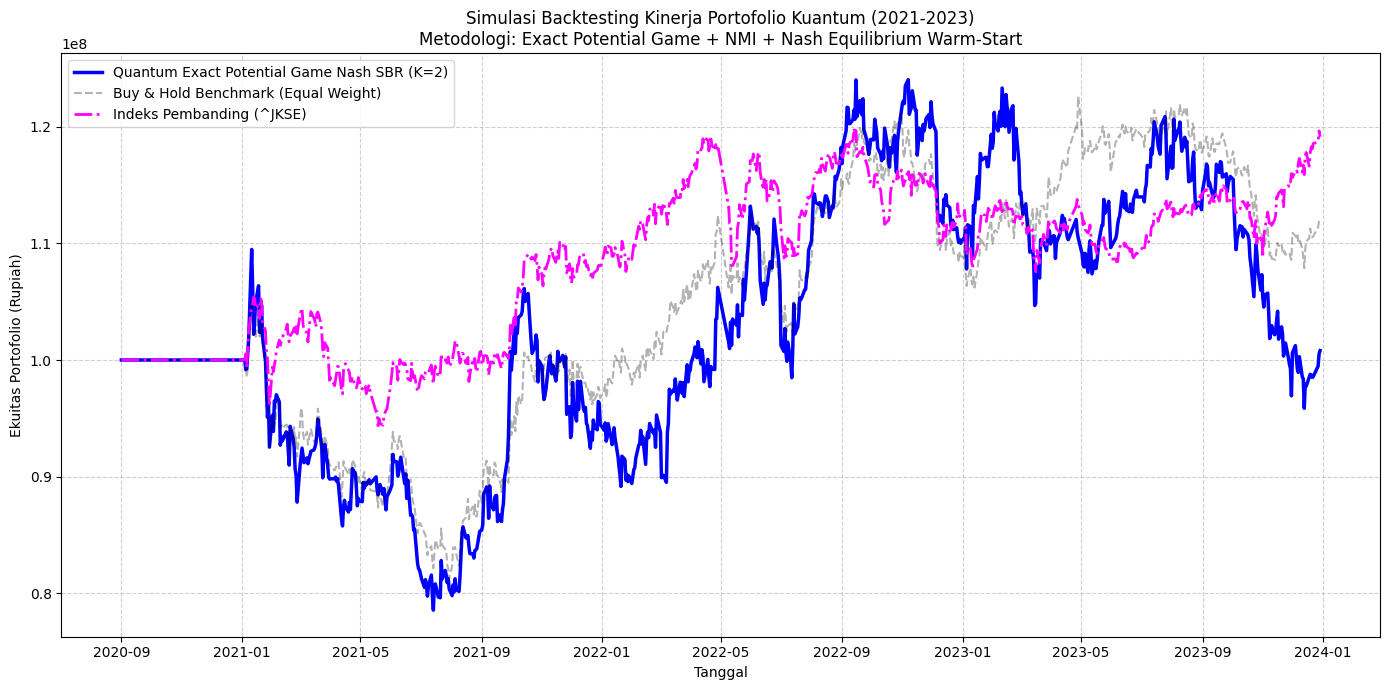


Grafik ditambah indeks ^JKSE berhasil diformat.


In [68]:
# =============================================================================
# 11. Visualisasi Pertumbuhan Portofolio
# =============================================================================
import yfinance as yf
plt.figure(figsize=(14, 7))

dates = data_clean.index

# --- Download & Process Benchmark Index ---
# Indeks pembanding dapat diubah-ubah di sini sesuai saham pilihan
benchmark_ticker = '^JKSE'
try:
    print(f"Mengunduh data indeks pembanding: {benchmark_ticker}...")
    bench_raw = yf.download(benchmark_ticker, start=dates[0], end=dates[-1] + pd.Timedelta(days=5), progress=False)['Close']
    if isinstance(bench_raw, pd.DataFrame) and benchmark_ticker in bench_raw.columns:
        bench_raw = bench_raw[benchmark_ticker]
    # Align dates
    bench_aligned = bench_raw.reindex(dates).ffill().bfill()
    value_ihsg = np.full(len(dates), initial_capital)
    start_bench_price = bench_aligned.iloc[start_idx]
    value_ihsg[start_idx:] = initial_capital * (bench_aligned.iloc[start_idx:] / start_bench_price).values
except Exception as e:
    print(f"Gagal mengunduh {benchmark_ticker}: {e}")
    value_ihsg = None

plt.plot(dates[:len(value_nash)],   value_nash,
         label=f'Quantum Exact Potential Game Nash SBR (K={K})',
         linewidth=2.5, color='blue')

# Transparansi ditingkatkan (alpha=0.3) agar fokus pada benchmark utama
plt.plot(dates[:len(value_bench)], value_bench,
         label='Buy & Hold Benchmark (Equal Weight)',
         linewidth=1.5, color='black', linestyle='--', alpha=0.3)

if value_ihsg is not None:
    plt.plot(dates[:len(value_ihsg)], value_ihsg[:len(value_ihsg)],
             label=f'Indeks Pembanding ({benchmark_ticker})',
             linewidth=2.0, color='magenta', linestyle='-.')

# colors = ['red', 'green', 'orange', 'purple', 'pink', 'grey', 'cyan', 'magenta']
# for j, t in enumerate(tickers):
#     plt.plot(dates[:len(value_assets[t])], value_assets[t],
#              label=f'Buy & Hold {t}', color=colors[j], alpha=0.2)

plt.title(
    'Simulasi Backtesting Kinerja Portofolio Kuantum (2021-2023)\n'
    'Metodologi: Exact Potential Game + NMI + Nash Equilibrium Warm-Start'
)
plt.ylabel('Ekuitas Portofolio (Rupiah)')
plt.xlabel('Tanggal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('backtest_result.png', dpi=150)
plt.show()
print(f"\nGrafik ditambah indeks {benchmark_ticker} berhasil diformat.")
